In [1]:
import pandas as pd

# read the csv file
df = pd.read_csv("SC_subjects.csv")

# view first few rows
df.head()

,subject,night,age,sex (F=1),LightsOff
0,0,1,33,1,0:38
1,0,2,33,1,21:57
2,1,1,33,1,22:44
3,1,2,33,1,22:15
4,2,1,26,1,22:50


In [2]:
subjects_one_night = (
    df.groupby("subject")
      .size()
      .loc[lambda x: x == 1]
      .index
      .tolist()
)

subjects_one_night

[13, 36, 52]

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

# load dataset
df = pd.read_csv("sleepedf_SC_merged_epochs.csv")

In [4]:
df.shape
df.columns

Index(['recording_id', 'epoch', 'epoch_start_sec', 'epoch_end_sec',
       'sleep_stage', 'EEG Fpz-Cz_mean', 'EEG Fpz-Cz_std', 'EEG Fpz-Cz_rms',
       'EEG Pz-Oz_mean', 'EEG Pz-Oz_std', 'EEG Pz-Oz_rms',
       'EOG horizontal_mean', 'EOG horizontal_std', 'EOG horizontal_rms',
       'EMG submental_mean', 'EMG submental_std', 'EMG submental_rms',
       'psg_file', 'hyp_file'],
      dtype='object')

In [5]:
df['recording_id'].nunique()
df['recording_id'].value_counts().head()

recording_id
4482    2880
4481    2880
4572    2873
4272    2870
4651    2860
Name: count, dtype: int64

In [6]:
def check_epoch_continuity(data):
    gaps = {}
    for rid, group in data.groupby('recording_id'):
        epochs = group['epoch'].sort_values().values
        if not np.all(np.diff(epochs) == 1):
            gaps[rid] = epochs
    return gaps

epoch_gaps = check_epoch_continuity(df)
len(epoch_gaps)  # should be 0 ideally

48

In [10]:
stage_counts = df['sleep_stage'].value_counts(normalize=True) * 100
stage_counts

sleep_stage
W      68.785500
N2     16.659879
REM     6.225886
N1      5.186512
N3      3.142223
Name: proportion, dtype: float64

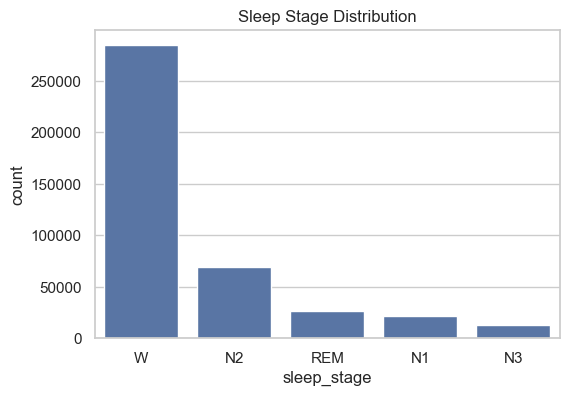

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sleep_stage', order=df['sleep_stage'].value_counts().index)
plt.title("Sleep Stage Distribution")
plt.show()

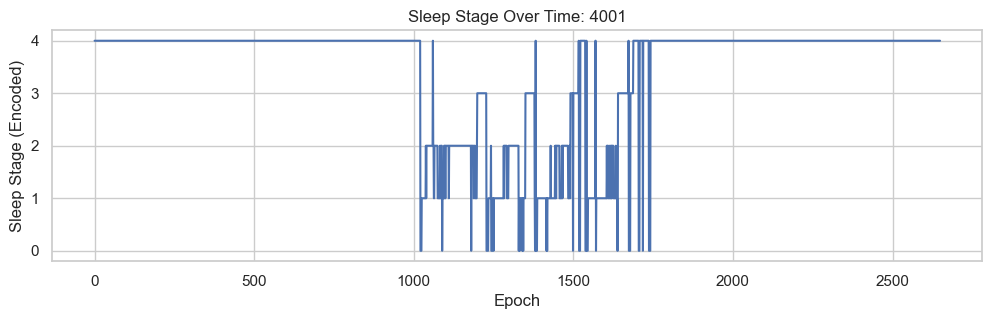

In [12]:
example_id = df['recording_id'].iloc[0]

plt.figure(figsize=(12,3))
sns.lineplot(
    data=df[df['recording_id'] == example_id],
    x='epoch',
    y=df[df['recording_id'] == example_id]['sleep_stage'].astype('category').cat.codes
)
plt.title(f"Sleep Stage Over Time: {example_id}")
plt.xlabel("Epoch")
plt.ylabel("Sleep Stage (Encoded)")
plt.show()


In [13]:
feature_cols = [
    col for col in df.columns
    if any(x in col for x in ['EEG', 'EOG', 'EMG']) and 'file' not in col
]

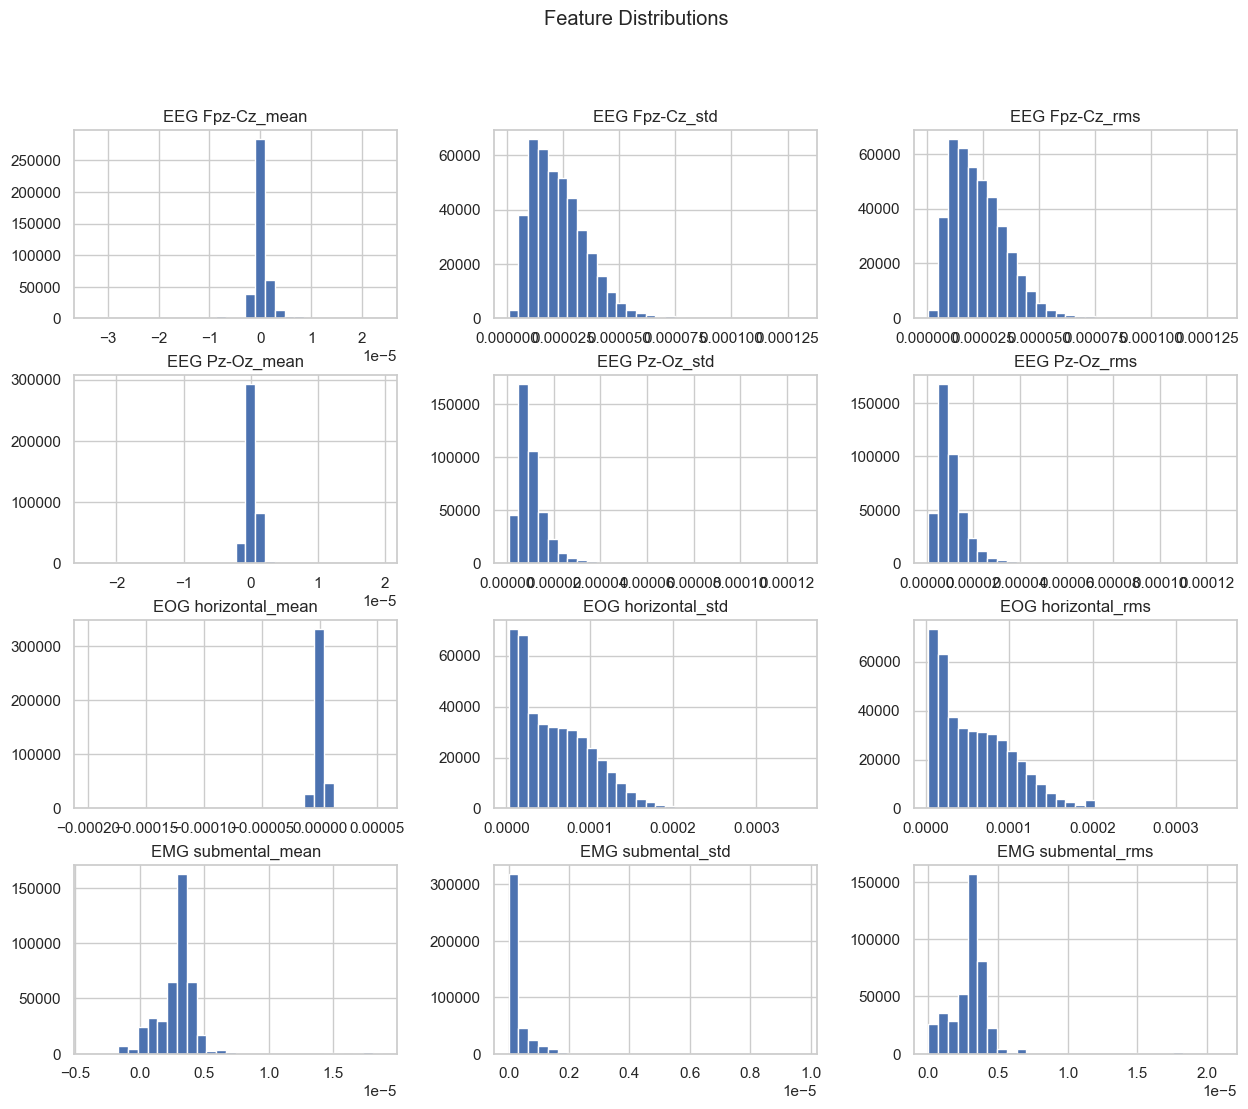

In [14]:
df[feature_cols].hist(figsize=(15,12), bins=30)
plt.suptitle("Feature Distributions")
plt.show()

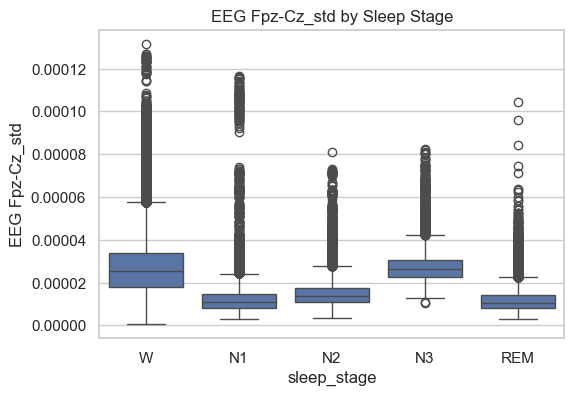

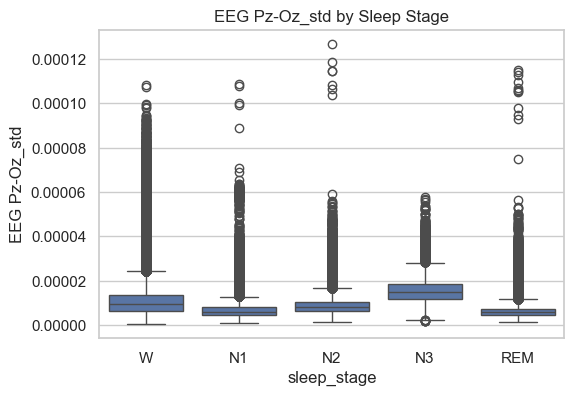

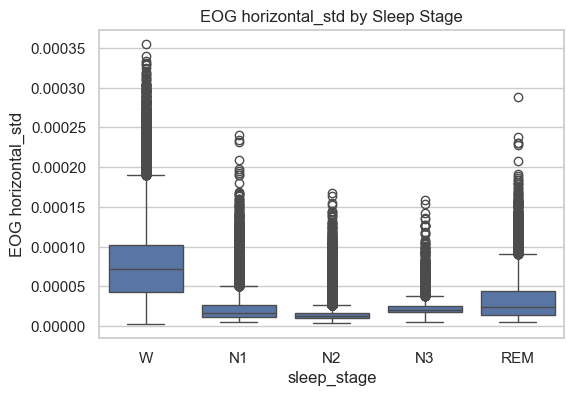

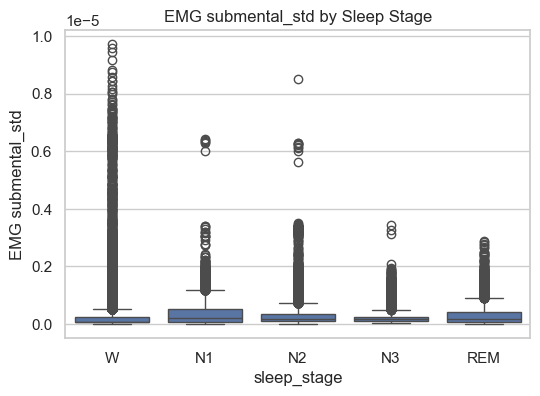

In [15]:
selected_features = [
    'EEG Fpz-Cz_std',
    'EEG Pz-Oz_std',
    'EOG horizontal_std',
    'EMG submental_std'
]

for feature in selected_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='sleep_stage', y=feature)
    plt.title(f"{feature} by Sleep Stage")
    plt.show()


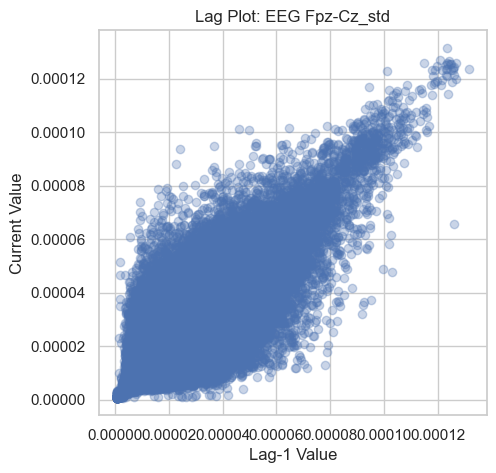

In [13]:
feature = 'EEG Fpz-Cz_std'

df_sorted = df.sort_values(['recording_id', 'epoch'])
df_sorted['lag_1'] = df_sorted.groupby('recording_id')[feature].shift(1)

plt.figure(figsize=(5,5))
plt.scatter(df_sorted['lag_1'], df_sorted[feature], alpha=0.3)
plt.xlabel("Lag-1 Value")
plt.ylabel("Current Value")
plt.title(f"Lag Plot: {feature}")
plt.show()

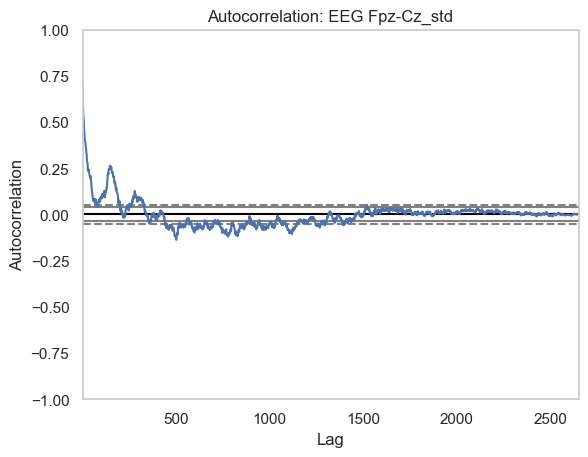

In [14]:
from pandas.plotting import autocorrelation_plot

example_series = df_sorted[df_sorted['recording_id'] == example_id][feature]
autocorrelation_plot(example_series)
plt.title(f"Autocorrelation: {feature}")
plt.show()

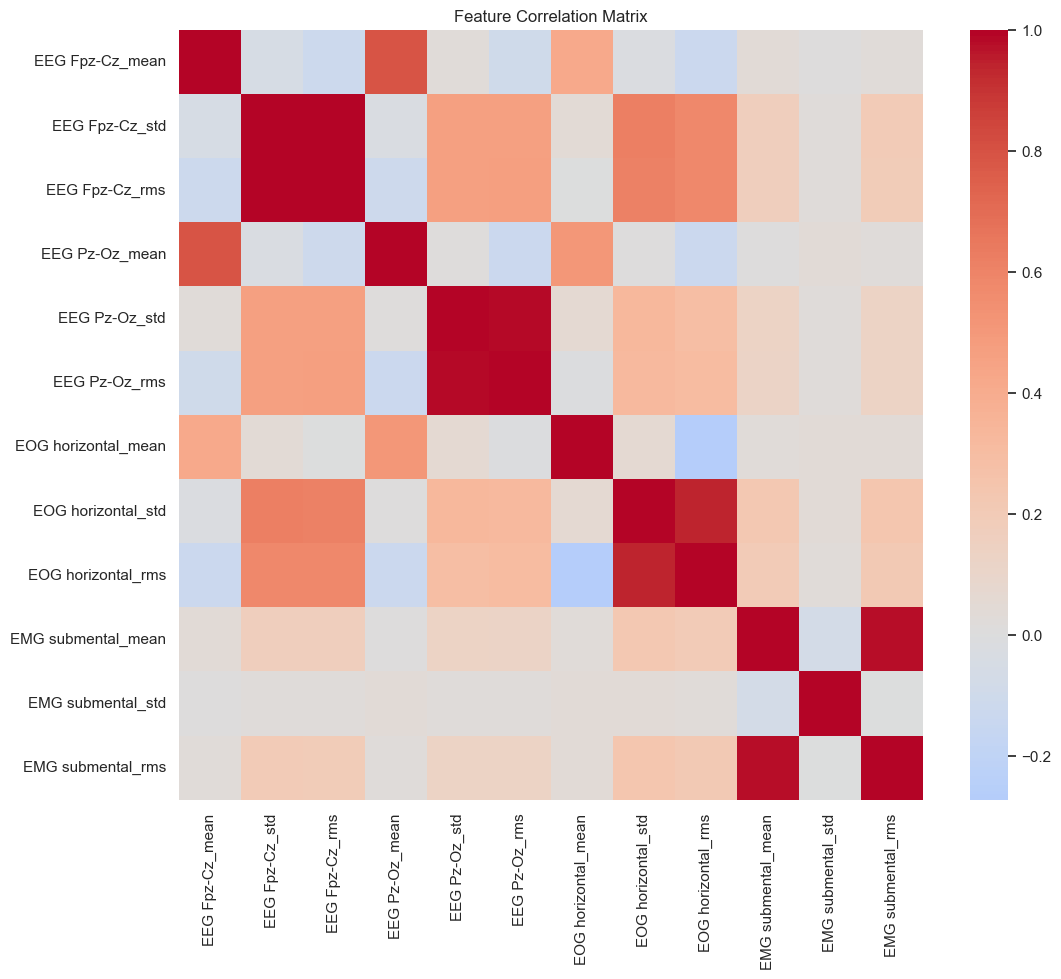

In [15]:
corr = df[feature_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [16]:
df_sorted['next_stage'] = df_sorted.groupby('recording_id')['sleep_stage'].shift(-1)

transition_matrix = pd.crosstab(
    df_sorted['sleep_stage'],
    df_sorted['next_stage'],
    normalize='index'
)

transition_matrix

next_stage,N1,N2,N3,REM,W
sleep_stage,,,,,
N1,0.724176,0.158310,0.000372,0.028484,0.088658
N2,0.026630,0.908277,0.038260,0.011905,0.014928
N3,0.005752,0.187131,0.796073,0.000997,0.010047
REM,0.027714,0.013083,0.000039,0.940972,0.018192
W,0.011585,0.000547,0.000018,0.000266,0.987584


In [17]:
df.isna().sum().sort_values(ascending=False)

recording_id           0
epoch                  0
epoch_start_sec        0
epoch_end_sec          0
sleep_stage            0
EEG Fpz-Cz_mean        0
EEG Fpz-Cz_std         0
EEG Fpz-Cz_rms         0
EEG Pz-Oz_mean         0
EEG Pz-Oz_std          0
EEG Pz-Oz_rms          0
EOG horizontal_mean    0
EOG horizontal_std     0
EOG horizontal_rms     0
EMG submental_mean     0
EMG submental_std      0
EMG submental_rms      0
psg_file               0
hyp_file               0
night                  0
dtype: int64

In [18]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df[feature_cols]))
outlier_rows = (z_scores > 5).any(axis=1)

outlier_rows.sum()

np.int64(11521)

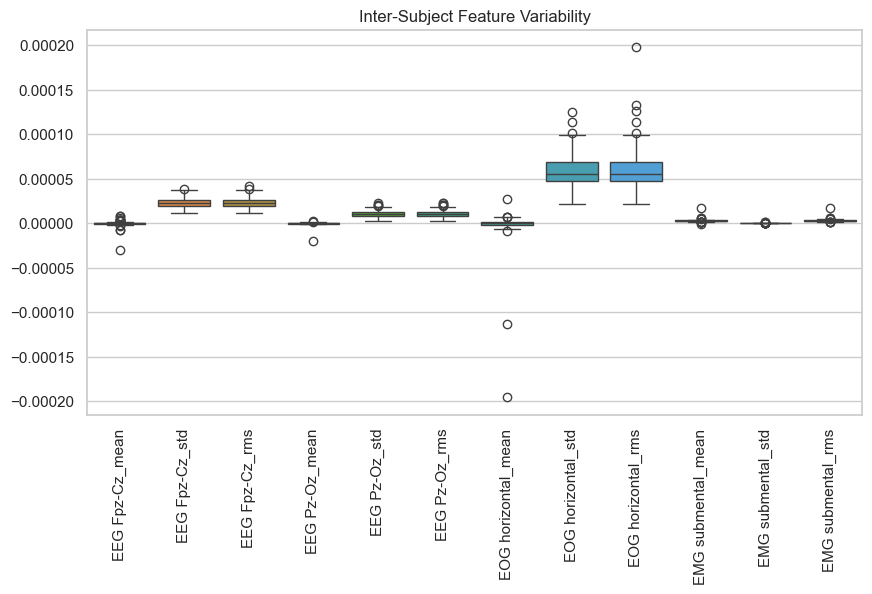

In [19]:
subject_means = df.groupby('recording_id')[feature_cols].mean()

plt.figure(figsize=(10,5))
sns.boxplot(data=subject_means)
plt.title("Inter-Subject Feature Variability")
plt.xticks(rotation=90)
plt.show()